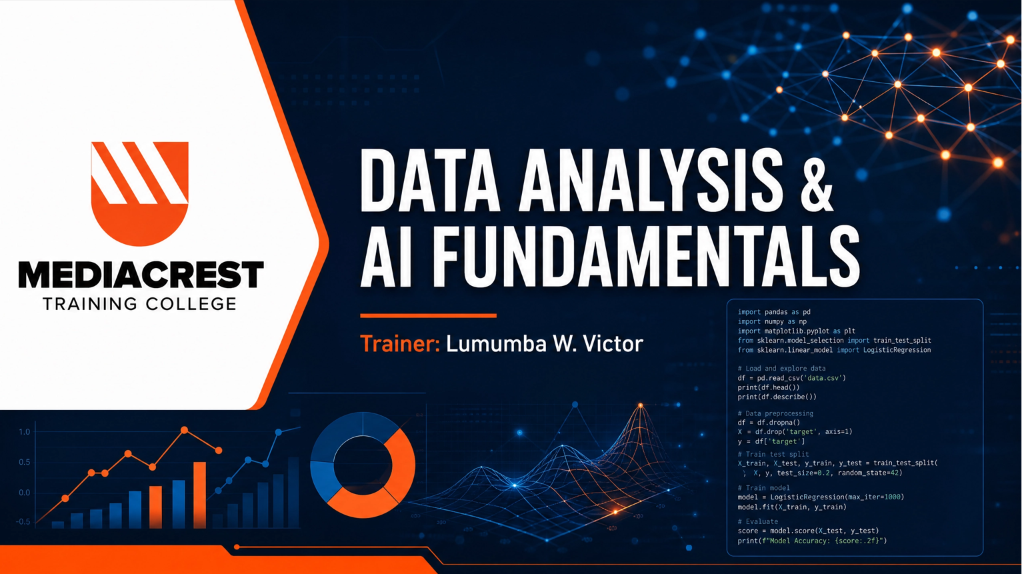

## **DATA VISUALIZATION AND INSIGHTS EXTRACTION**
* Univariate Analysis(Categorical or Continuous)
* Bivariate Analysis (Categorical or Continuous)
* Multivariate Analysis (Continuous)
* Advanced Plots and Charts

### **1. LOAD THE REQUIRED LIBRARIES**

In [2]:
#!pip install mpl_toolkits

In [3]:
import pandas as pd                       ## For data importation and dataframes manipulation
import numpy as np                        ## For Numeric Manipulation
import seaborn as sns                     ## For data visualization
import matplotlib.pyplot as plt           ## For data visualization
#from mpl_toolkits.mplt3d import Axes3D   ## For 3D Visualization

### Import warnings
import warnings                           ### For ignoring the warning messages
warnings.filterwarnings('ignore')        

### **1.1. SET UP THE VISUALIZATION STYLE**

In [4]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["font.size"] = 10

### **1.2. DATA IMPORTATION**

In [5]:
df = pd.read_csv("GSSsubset.csv")
df.head()

,id,sex,degree,income,marital,age,height,weight,hrswrk
0,1,MALE,BACHELOR,60967.50,DIVORCED,53,72,190,60
1,2,FEMALE,BACHELOR,60967.50,MARRIED,26,60,97,40
2,4,FEMALE,BACHELOR,10161.25,MARRIED,56,68,160,20
3,14,FEMALE,HIGH SCHOOL,17551.25,MARRIED,40,65,156,37
4,16,MALE,HIGH SCHOOL,17551.25,MARRIED,56,66,210,6


### **1.3. CHECK THE BASIC DATA INFORMATION**

In [6]:
### Dimension of the Data
print("="*110)
print("CHECKING THE BASIC DATA INFORMATION")
print("="*110)
print(f"Display the dimension of the data: {df.shape}")
print(f"Display the column list: {list(df.columns)}")
print(f"Display the types of the Variables: {df.info()}")


CHECKING THE BASIC DATA INFORMATION
Display the dimension of the data: (994, 9)
Display the column list: ['id', 'sex', 'degree', 'income', 'marital', 'age', 'height', 'weight', 'hrswrk']
<class 'pandas.DataFrame'>
RangeIndex: 994 entries, 0 to 993
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       994 non-null    int64  
 1   sex      994 non-null    str    
 2   degree   994 non-null    str    
 3   income   994 non-null    float64
 4   marital  994 non-null    str    
 5   age      994 non-null    int64  
 6   height   994 non-null    int64  
 7   weight   994 non-null    int64  
 8   hrswrk   994 non-null    int64  
dtypes: float64(1), int64(5), str(3)
memory usage: 93.7 KB
Display the types of the Variables: None


### **2. UNIVARIATE DATA VISUALIZATION**

#### **2.1. Histogram For the Distribution of Income**

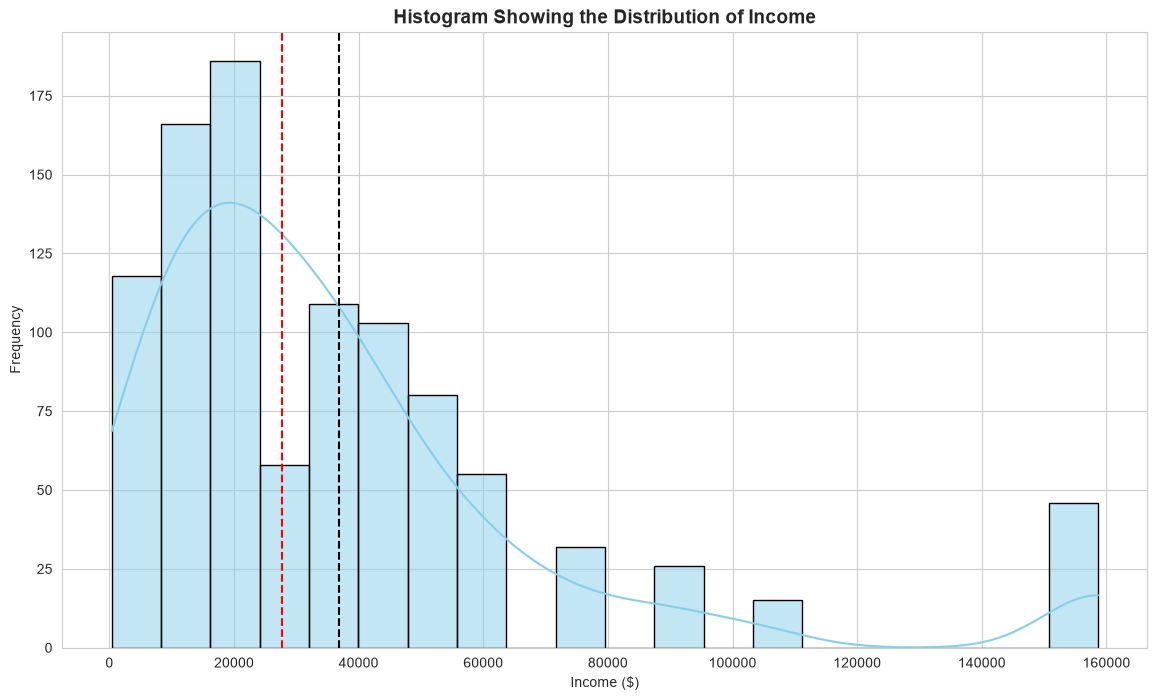

In [12]:
plt.figure(figsize = (14, 8))
sns.histplot(df['income'], bins = 20, kde = True,
            color = "skyblue", edgecolor = "black")
plt.title("Histogram Showing the Distribution of Income", fontsize = 14, fontweight = "bold")
plt.xlabel("Income ($)")
plt.ylabel("Frequency")

plt.axvline(df['income'].median(), color = 'red',
            linestyle = '--',
            label = f'Median: ${df['income'].median():,.0f}')

plt.axvline(df['income'].mean(), color = 'black',
            linestyle = '--',
            label = f'Mean: ${df['income'].mean():,.0f}')
plt.show()

Comparing the mean and median is a quick way to identify skewness (asymmetry) in a dataset. Because the mean is sensitive to extreme outliers, it shifts toward the "tail" of the data, while the median represents the middle point.
1. Zero Skew (Symmetrical)

Rule: Mean = Median.

Shape: The distribution looks like a classic, symmetrical bell curve when graphed on a Scribbr Skewness Guide.

2. Right/Positive Skew

Rule: Mean > Median

Shape: The data features a long tail extending toward the higher, positive numbers. The extreme high values pull the mean up, while the median stays closer to the bulk of the data.

3. Left/Negative Skew

Rule: Mean < Median
Shape: The data features a long tail extending toward the lower, negative numbers. The extreme low values pull the mean down, leaving the median higher than the mean.

In [15]:
df.drop(columns = ['id']).describe()

,income,age,height,weight,hrswrk
count,994.000000,994.000000,994.000000,994.000000,994.000000
mean,36887.218352,44.488934,67.414487,181.318913,42.640845
std,34702.256068,13.126865,4.037741,41.641615,14.394974
min,369.500000,19.000000,57.000000,90.000000,1.000000
25%,15703.750000,33.000000,64.000000,150.000000,38.000000
50%,27712.500000,44.000000,67.000000,175.000000,40.000000
75%,49882.500000,55.000000,70.000000,205.000000,50.000000
max,158656.952000,79.000000,79.000000,410.000000,89.000000


#### **2.2. Distribution of Income Using Box Plot**

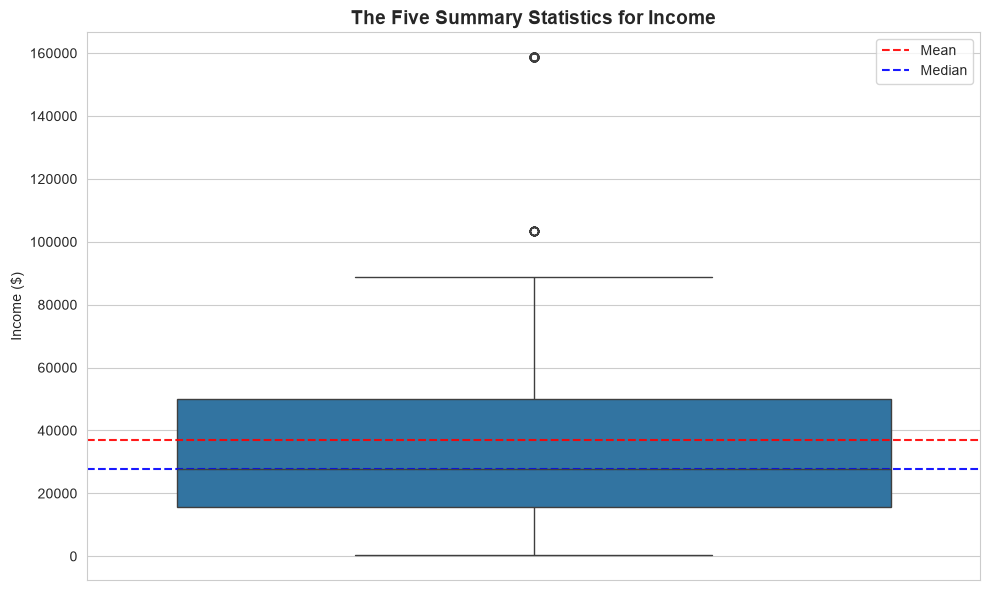

In [20]:
plt.figure(figsize = (10, 6))   ### Initialize the figure size
sns.boxplot(y = df['income'])    ### Pick the type of chart
plt.title("The Five Summary Statistics for Income", 
          fontsize = 14,
          fontweight = 'bold')
plt.ylabel("Income ($)")

plt.axhline(df['income'].mean(), color = "red",
            linestyle = '--', alpha = 0.9, label = 'Mean')

plt.axhline(df['income'].median(), color = "blue",
            linestyle = '--', alpha = 0.9, label = 'Median')
plt.legend()
plt.tight_layout()
          
plt.show()                      ### Display the chart

#### **2.3. Violin and Histogram for the Distribution of Ages**

In [22]:
df.head()

,id,sex,degree,income,marital,age,height,weight,hrswrk
0,1,MALE,BACHELOR,60967.50,DIVORCED,53,72,190,60
1,2,FEMALE,BACHELOR,60967.50,MARRIED,26,60,97,40
2,4,FEMALE,BACHELOR,10161.25,MARRIED,56,68,160,20
3,14,FEMALE,HIGH SCHOOL,17551.25,MARRIED,40,65,156,37
4,16,MALE,HIGH SCHOOL,17551.25,MARRIED,56,66,210,6


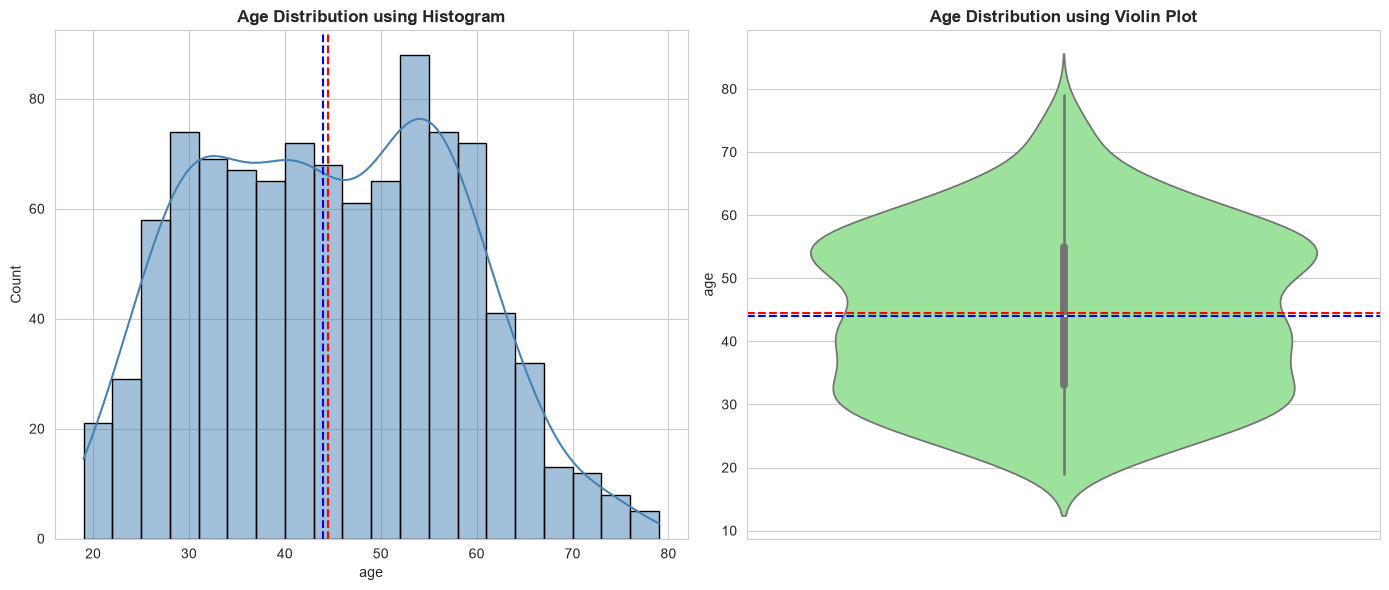

In [30]:
fig, axes = plt.subplots(1, 2, figsize = (14, 6))

sns.histplot(df['age'], bins = 20, kde = True, ax = axes[0],
             color = 'steelblue', edgecolor = 'black')
axes[0].set_title("Age Distribution using Histogram", 
                  fontsize = 12, 
                  fontweight = 'bold')
axes[0].axvline(df['age'].mean(), color = 'red',
            linestyle = '--',
            label = f'Mean: ${df['age'].mean():,.0f}')
axes[0].axvline(df['age'].median(), color = 'blue',
            linestyle = '--',
            label = f'Median: ${df['age'].median():,.0f}')


sns.violinplot(y = df['age'], ax = axes[1], color = 'lightgreen')
axes[1].set_title("Age Distribution using Violin Plot", 
                  fontsize = 12, 
                  fontweight = 'bold')
axes[1].axhline(df['age'].mean(), color = 'red',
            linestyle = '--',
            label = f'Mean: ${df['age'].mean():,.0f}')
axes[1].axhline(df['age'].median(), color = 'blue',
            linestyle = '--',
            label = f'Median: ${df['age'].median():,.0f}')
plt.tight_layout()
plt.show()

#### **2.4. Scatter Plot Showing the Relationship Between Age and Income**

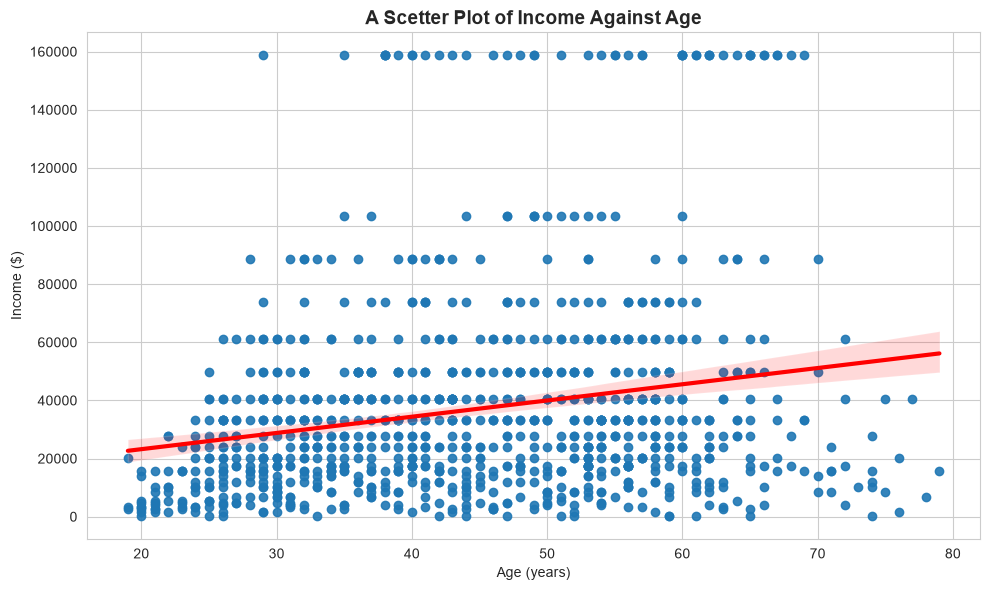

In [33]:
plt.figure(figsize = (10, 6))
sns.regplot(data = df, x = 'age', y = 'income', scatter_kws = {'alpha': 0.9},
            line_kws = {'color': 'red', 'linewidth': 3})
plt.title("A Scetter Plot of Income Against Age", 
          fontsize = 14,
          fontweight = "bold")
plt.xlabel("Age (years)")
plt.ylabel("Income ($)")

plt.tight_layout()
plt.show()

#### **2.4. Scatter Plot Showing the Relationship Between Age and Income**

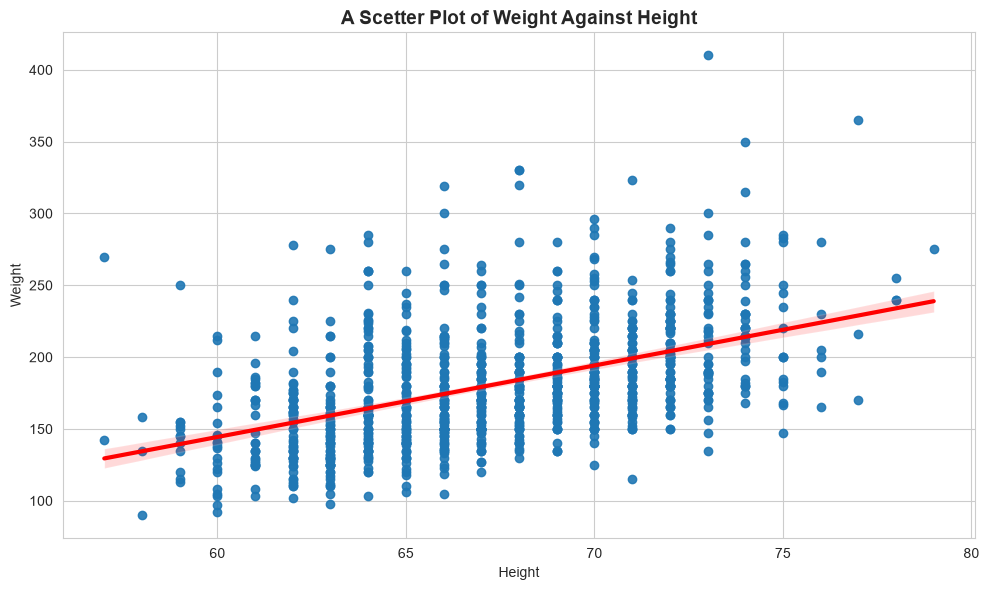

In [34]:
plt.figure(figsize = (10, 6))
sns.regplot(data = df, x = 'height', y = 'weight', scatter_kws = {'alpha': 0.9},
            line_kws = {'color': 'red', 'linewidth': 3})
plt.title("A Scetter Plot of Weight Against Height", 
          fontsize = 14,
          fontweight = "bold")
plt.xlabel("Height")
plt.ylabel("Weight")

plt.tight_layout()
plt.show()

#### **2.5. Joint Distribution PLot of Weight Against Height**

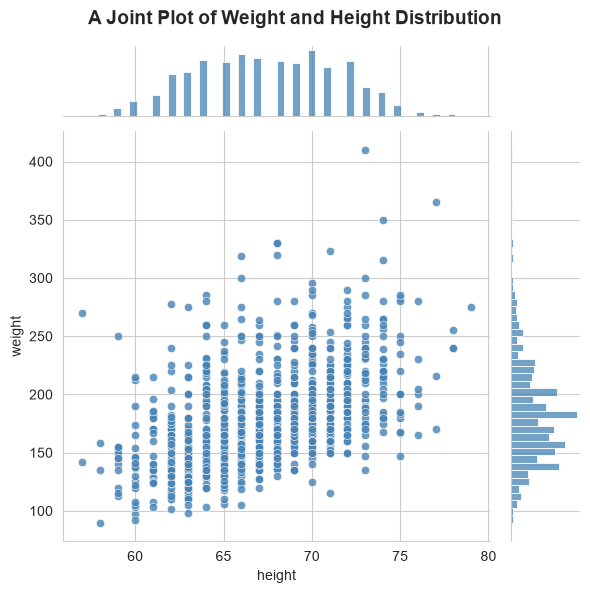

In [38]:
joint_plot = sns.jointplot(data = df, x = "height", y = "weight",
                           kind = 'scatter', alpha = 0.8, color = 'steelblue',
                           marginal_kws = dict(bins = 50, fill = True)
                          )
joint_plot.fig.suptitle('A Joint Plot of Weight and Height Distribution',
                        fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

In [40]:
print('='*110)
print(f"Correlation Between Weight and Height")
print('='*110)
corr_val = df['height'].corr(df['weight'])
print(f"Correlation: {corr_val:.3f}")

Correlation Between Weight and Height
Correlation: 0.482


### **3. Categorical Variables Analysis**

#### **3.1. Bar Showing the Distribution of Gender**

In [47]:
df['sex'].value_counts()

sex
MALE      507
FEMALE    487
Name: count, dtype: int64

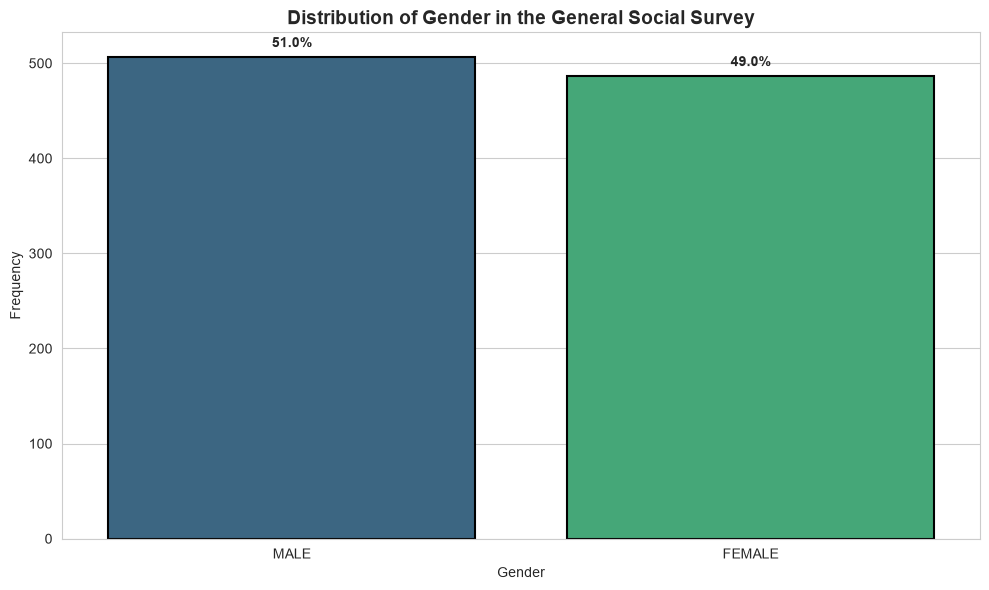

In [53]:
plt.figure(figsize = (10,6))
ax = sns.countplot(data = df, x = "sex", palette = 'viridis',
                   edgecolor = 'black', linewidth = 1.5)

plt.title("Distribution of Gender in the General Social Survey",
          fontsize = 14, 
          fontweight = 'bold')

plt.xlabel("Gender")
plt.ylabel("Frequency")

total = len(df)
for p in ax.patches:
    percentage = f'{100*p.get_height()/total:.1f}%'
    x = p.get_x() + p.get_width()/2
    y = p.get_height()+10
    ax. annotate (percentage, (x, y), 
                  ha = 'center', 
                  fontweight = 'bold')

plt.tight_layout()
plt.show()

#### **3.2. Bar Showing the Distribution of Degree Qualification**

In [59]:
Frequency_table = df['degree'].value_counts().sort_values()
Frequency_table

degree
LT HIGH SCHOOL     77
JUNIOR COLLEGE     92
GRADUATE          125
BACHELOR          209
HIGH SCHOOL       491
Name: count, dtype: int64

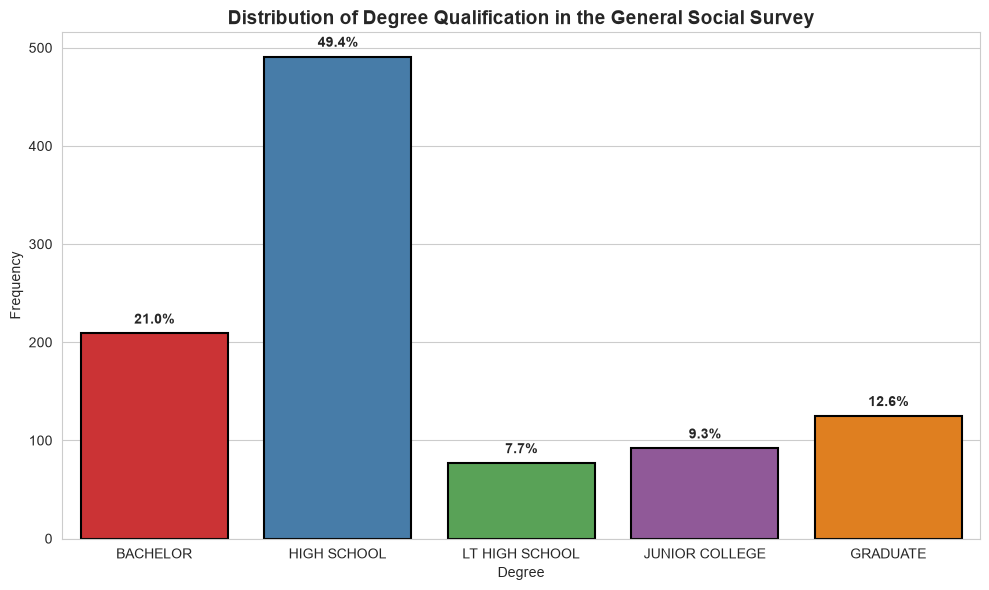

In [55]:
plt.figure(figsize = (10,6))
ax = sns.countplot(data = df, x = "degree", palette = 'Set1',
                   edgecolor = 'black', linewidth = 1.5)

plt.title("Distribution of Degree Qualification in the General Social Survey",
          fontsize = 14, 
          fontweight = 'bold')

plt.xlabel("Degree")
plt.ylabel("Frequency")

total = len(df)
for p in ax.patches:
    percentage = f'{100*p.get_height()/total:.1f}%'
    x = p.get_x() + p.get_width()/2
    y = p.get_height()+10
    ax. annotate (percentage, (x, y), 
                  ha = 'center', 
                  fontweight = 'bold')

plt.tight_layout()
plt.show()

#### **3.2. Bar Showing the Distribution of Degree Qualification**

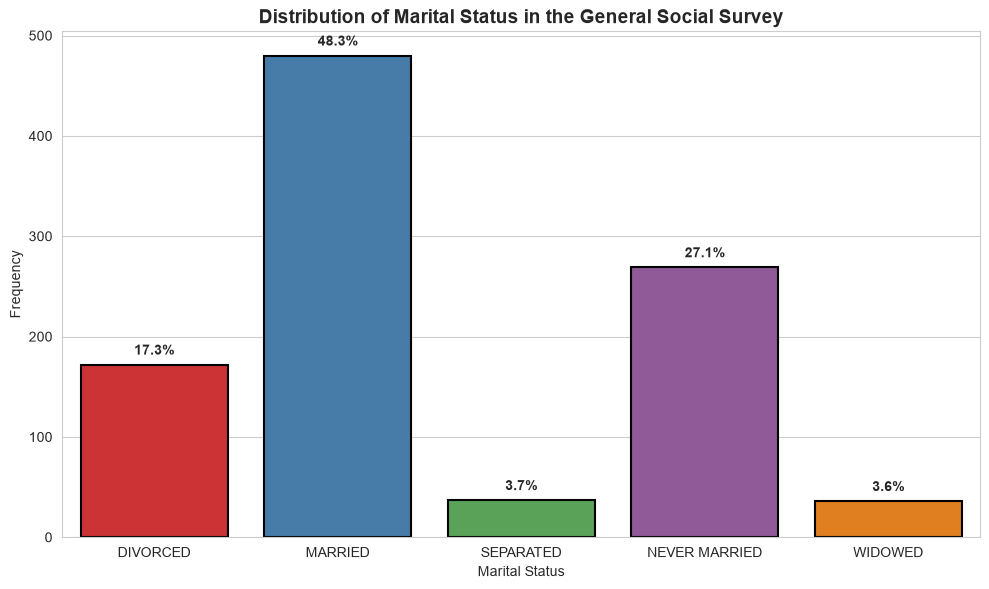

In [60]:
plt.figure(figsize = (10,6))
ax = sns.countplot(data = df, x = "marital", palette = 'Set1',
                   edgecolor = 'black', linewidth = 1.5)

plt.title("Distribution of Marital Status in the General Social Survey",
          fontsize = 14, 
          fontweight = 'bold')

plt.xlabel("Marital Status")
plt.ylabel("Frequency")

total = len(df)
for p in ax.patches:
    percentage = f'{100*p.get_height()/total:.1f}%'
    x = p.get_x() + p.get_width()/2
    y = p.get_height()+10
    ax. annotate (percentage, (x, y), 
                  ha = 'center', 
                  fontweight = 'bold')

plt.tight_layout()
plt.show()